# 🧪 Lab 01: Classificação de Imagens com CNN no PyTorch
**Módulo:** `02-deep-learning / computer-vision-nlp`

## Objetivos
1. Introduzir o fluxo de trabalho com tensores e datasets no **PyTorch**.
2. Criar uma arquitetura de **Rede Neural Convolucional (CNN)** com `nn.Conv2d`, `nn.MaxPool2d` e `nn.Linear`.
3. Treinar e avaliar a rede no dataset Fashion-MNIST.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Verificar dispositivo (GPU/CUDA ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executando no dispositivo: {device}")

Executando no dispositivo: cpu


## 1. Carregamento e Preparação do Dataset (Fashion-MNIST)

100.0%
100.0%
100.0%
100.0%


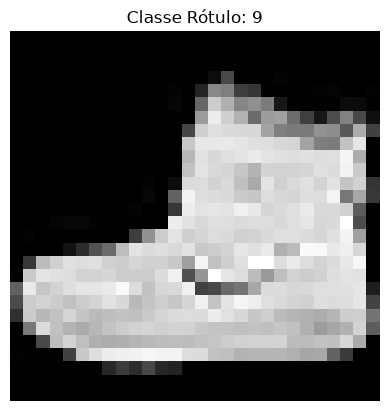

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Visualizar 1 exemplo
image, label = train_dataset[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Classe Rótulo: {label}")
plt.axis('off')
plt.show()

## 2. Definição da Arquitetura da CNN

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 3. Treinamento Rápido (3 Épocas)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Época [{epoch+1}/{epochs}] - Perda (Loss): {running_loss/len(train_loader):.4f}")

print("✅ Treinamento da CNN concluído!")

Época [1/3] - Perda (Loss): 0.4676
Época [2/3] - Perda (Loss): 0.3049
Época [3/3] - Perda (Loss): 0.2602
✅ Treinamento da CNN concluído!
